In [5]:
%reload_ext autoreload
%autoreload 2

from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

sim = MiniprojectSimulation(level=3, seed=42)
controller = Controller(sim)

for _ in trange(70000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

sim.renderer.show_in_notebook()

KeyboardInterrupt: 

100%|██████████| 7000/7000 [00:02<00:00, 2547.64it/s]


nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


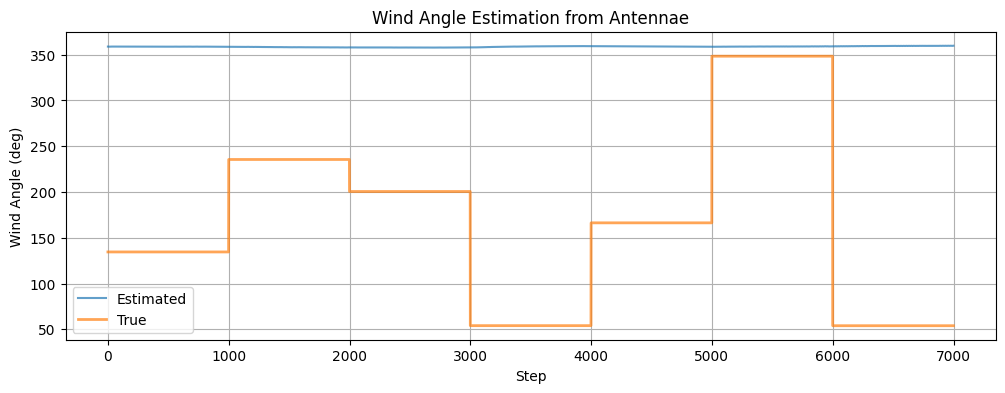

In [12]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

wind_angle_history = []
true_wind_angle_history = []

sim = MiniprojectSimulation(level=3, seed=42)
controller = Controller(sim)

for _ in trange(7000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    wind_angle_history.append(controller.wind_angle_estimate)
    # Extract true wind angle from flow velocity
    wind_vec = sim.world.flow_velocity[:2]
    true_angle = np.rad2deg(np.arctan2(wind_vec[1], wind_vec[0])) % 360
    true_wind_angle_history.append(true_angle)
    sim.render_as_needed()

sim.renderer.show_in_notebook()

# Plot after simulation
plt.figure(figsize=(12, 4))
plt.plot(wind_angle_history, label="Estimated", alpha=0.7)
plt.plot(true_wind_angle_history, label="True", alpha=0.7, linewidth=2)
plt.xlabel("Step")
plt.ylabel("Wind Angle (deg)")
plt.title("Wind Angle Estimation from Antennae")
plt.grid(True)
plt.legend()
plt.show()

100%|██████████| 7000/7000 [00:02<00:00, 2480.90it/s]


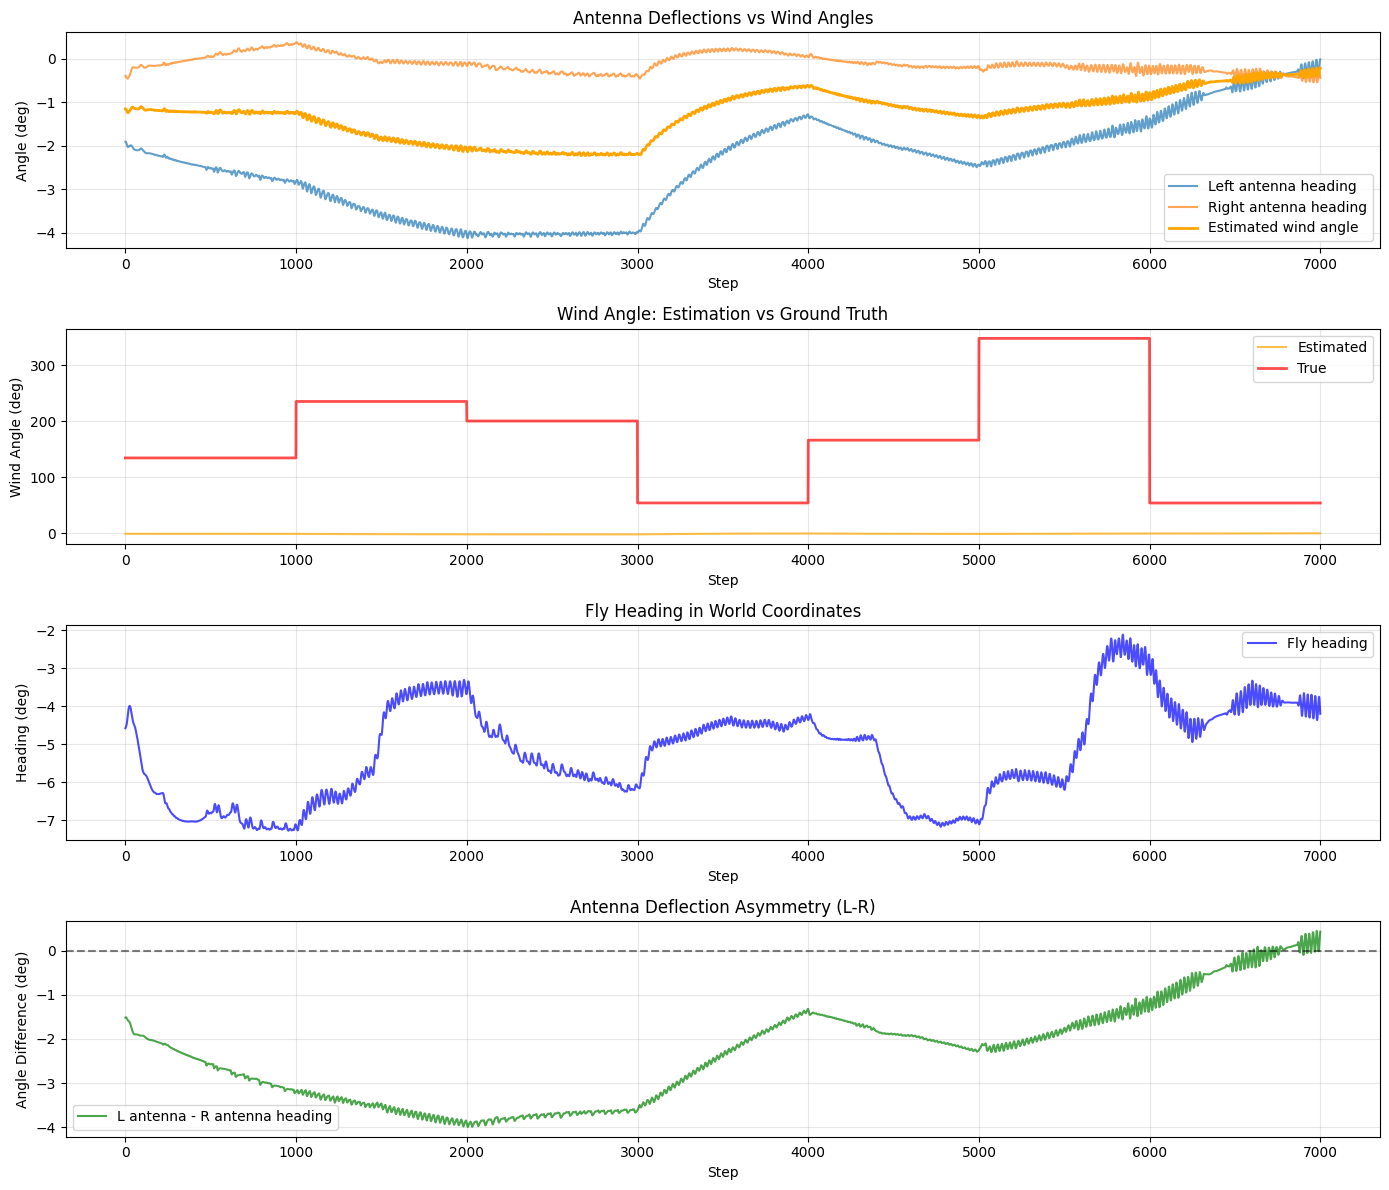

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller, antenna_qpos_to_heading_deg

# Collect antenna and fly heading data over time
wind_angle_history = []
true_wind_angle_history = []
left_antenna_heading = []
right_antenna_heading = []
fly_heading_history = []

sim = MiniprojectSimulation(level=3, seed=42)
controller = Controller(sim)

def quat_to_heading_deg(quat):
    w, x, y, z = quat
    R = np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - z*w), 2*(x*z + y*w)],
        [2*(x*y + z*w), 1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w), 2*(y*z + x*w), 1 - 2*(x*x + y*y)],
    ])
    heading_vec = R[:2, 0]
    return np.rad2deg(np.arctan2(heading_vec[1], heading_vec[0]))

for _ in trange(7000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    
    body_segs = list(sim.fly.get_bodysegs_order())
    thorax_idx = next(i for i, seg in enumerate(body_segs) if seg.name == "c_thorax")
    thorax_quat = sim.get_body_rotations(sim.fly.name)[thorax_idx]
    fly_heading = quat_to_heading_deg(thorax_quat)
    fly_heading_history.append(fly_heading)

    antenna_data = sim.get_antenna_data(sim.fly.name)
    wind_angle_history.append(controller.wind_angle_estimate)
    
    wind_vec = sim.world.flow_velocity[:2]
    true_angle = np.rad2deg(np.arctan2(wind_vec[1], wind_vec[0])) % 360
    true_wind_angle_history.append(true_angle)
    
    left_antenna_heading.append(antenna_qpos_to_heading_deg(antenna_data['l']['qpos']))
    right_antenna_heading.append(antenna_qpos_to_heading_deg(antenna_data['r']['qpos']))
    
    sim.render_as_needed()

# Plot
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Plot 1: Antenna headings vs wind angles
axes[0].plot(left_antenna_heading, label='Left antenna heading', alpha=0.7)
axes[0].plot(right_antenna_heading, label='Right antenna heading', alpha=0.7)
axes[0].plot(wind_angle_history, label='Estimated wind angle', linewidth=2, color='orange')
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Angle (deg)")
axes[0].set_title("Antenna Deflections vs Wind Angles")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Estimated vs True wind angle
axes[1].plot(wind_angle_history, label='Estimated', alpha=0.7, color='orange')
axes[1].plot(true_wind_angle_history, label='True', alpha=0.7, color='red', linewidth=2)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Wind Angle (deg)")
axes[1].set_title("Wind Angle: Estimation vs Ground Truth")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Fly heading history
axes[2].plot(fly_heading_history, label='Fly heading', alpha=0.7, color='blue')
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Heading (deg)")
axes[2].set_title("Fly Heading in World Coordinates")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Left - Right antenna heading difference
antenna_diff = np.array(left_antenna_heading) - np.array(right_antenna_heading)
antenna_diff = np.where(antenna_diff > 180, antenna_diff - 360, antenna_diff)
antenna_diff = np.where(antenna_diff < -180, antenna_diff + 360, antenna_diff)

axes[3].plot(antenna_diff, label='L antenna - R antenna heading', alpha=0.7, color='green')
axes[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[3].set_xlabel("Step")
axes[3].set_ylabel("Angle Difference (deg)")
axes[3].set_title("Antenna Deflection Asymmetry (L-R)")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()